# LECTURE 1
**Topic:** Complex Numbers  
**Textbook References:** Section 1.3

---

## Key Points

- A complex number $z$ is a point on a two-dimensional plane (the **complex plane**). It can be specified using either **Cartesian** $(x, y)$ or **polar** $(r, \theta)$ coordinates.
- Addition and scaling of complex numbers follow the same rules as for two-dimensional **vectors**.


---
## Theory and Examples

### 1. The Complex Plane

A complex number $z$ is a point (or vector) on a two-dimensional plane, known as the **complex plane** and represented by $\mathbb{C}$.

The **Cartesian coordinates** of $z$ are:
$$x = \Re\{z\}, \quad \text{the real part of } z$$
$$y = \Im\{z\}, \quad \text{the imaginary part of } z$$

The corresponding axes are known as the **real axis** and **imaginary axis**, respectively.

The **polar coordinates** of $z$ are:
$$r = |z|, \quad \text{the modulus (magnitude) of } z$$
$$\theta = \angle z, \quad \text{the angle of } z$$


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

# Use a clean style
plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

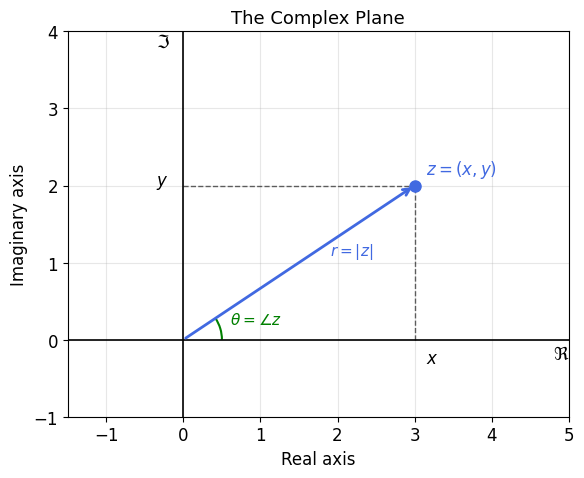

In [2]:
# ============================================================
# Figure 1: The Complex Plane — annotated diagram
# ============================================================
fig, ax = plt.subplots(figsize=(6, 6))

# --- Example point ---
x, y = 3.0, 2.0
r     = np.sqrt(x**2 + y**2)
theta = np.arctan2(y, x)

# --- Axes ---
ax.axhline(0, color='black', linewidth=1.2)
ax.axvline(0, color='black', linewidth=1.2)

# --- Vector arrow for z ---
ax.annotate('', xy=(x, y), xytext=(0, 0),
            arrowprops=dict(arrowstyle='->', color='royalblue', lw=2.0))

# --- Dashed projection lines ---
ax.plot([x, x], [0, y], 'k--', lw=1, alpha=0.6)   # vertical to real axis
ax.plot([0, x], [y, y], 'k--', lw=1, alpha=0.6)   # horizontal to imag axis

# --- Angle arc ---
arc = mpatches.Arc((0, 0), 1.0, 1.0, angle=0,
                   theta1=0, theta2=np.degrees(theta),
                   color='green', lw=1.5)
ax.add_patch(arc)

# --- Labels ---
ax.plot(x, y, 'o', color='royalblue', markersize=8)
ax.text(x + 0.15, y + 0.15, r'$z = (x, y)$', fontsize=12, color='royalblue')
ax.text(x + 0.15, -0.3, r'$x$', fontsize=12)
ax.text(-0.35, y,      r'$y$', fontsize=12)
ax.text(r/2 + 0.1, y/2 + 0.1, r'$r = |z|$', fontsize=11, color='royalblue')
ax.text(0.6, 0.2, r'$\theta = \angle z$', fontsize=11, color='green')

# --- Axis labels and formatting ---
ax.set_xlim(-1.5, 5)
ax.set_ylim(-1, 4)
ax.set_xlabel('Real axis', fontsize=12)
ax.set_ylabel('Imaginary axis', fontsize=12)
ax.set_title('The Complex Plane', fontsize=13)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')
ax.text(4.8, -0.25, r'$\Re$', fontsize=13)
ax.text(-0.35, 3.8, r'$\Im$', fontsize=13)

plt.tight_layout()
plt.show()

---
### 2. Coordinate Conversions

The usual rules for converting between Cartesian and polar coordinates apply:

$$x = r\cos\theta \qquad y = r\sin\theta$$

$$r = \sqrt{x^2 + y^2}$$

The angle $\theta$ is customarily quoted in **radians**.
Note that $2\pi \text{ rad} = 360^\circ$ (one full revolution), so angles differing by multiples of $2\pi$ are equivalent.

Usually $\theta$ is quoted in the interval $[0, 2\pi)$ or $(-\pi, \pi]$.

To obtain $\theta$ from $(x, y)$, use the **two-argument arctangent**:

$$\theta = \arctan\!\left(\frac{y}{x}\right) + \begin{cases}0 & \text{if } x > 0 \\ \pi & \text{if } x < 0\end{cases}$$

In other words, **add $\pi$ if and only if $x$ is negative**.

> ⚠️ **Common Mistake:** Using the single-argument `arctan(y/x)` (i.e., `np.arctan`) loses quadrant information. Always use `np.arctan2(y, x)` in code, which handles the $\pi$ correction automatically.


---
### 3. Example — Given $z_1$ and $z_2$, plot on the complex plane

Consider the complex numbers $z_1$ and $z_2$ where:

$$\Re\{z_1\} = -5, \quad \Im\{z_1\} = 2$$

$$|z_2| = 4, \quad \angle z_2 = \pi/6 \text{ rad}$$

**Task:** Plot these on the complex plane.

#### Solution for $z_1$ (Cartesian → Polar)

$$|z_1| = \sqrt{(-5)^2 + 2^2} = \sqrt{29} \approx 5.3852$$

$$\angle z_1 = \arctan\!\left(\frac{-2}{5}\right) + \pi = 2.7611 \text{ rad} = 158.2^\circ$$

Note: $\pi$ **was added** because the real part of $z_1$ ($x = -5$) is **negative** (i.e., $z_1$ lies in the second quadrant).

> ⚠️ **Common Mistake:** Forgetting to add $\pi$. `arctan(-2/5)` returns $\approx -0.3805$ rad (in the fourth quadrant), but $z_1$ is actually in the **second** quadrant. Adding $\pi$ corrects this to $2.7611$ rad.

#### Solution for $z_2$ (Polar → Cartesian)

$$\Re\{z_2\} = 4\cos(\pi/6) = 4 \cdot \frac{\sqrt{3}}{2} = 2\sqrt{3} \approx 3.4641$$

$$\Im\{z_2\} = 4\sin(\pi/6) = 4 \cdot \frac{1}{2} = 2$$


In [3]:
# ============================================================
# Step-by-step computation for z1 and z2
# ============================================================

# --- z1: given Cartesian, find polar ---
x1, y1 = -5, 2

r1 = np.sqrt(x1**2 + y1**2)          # modulus
theta1 = np.arctan2(y1, x1)          # angle (arctan2 handles quadrant automatically)

# Manual check: arctan(y/x) + pi
theta1_manual = np.arctan(y1 / x1) + np.pi   # x1 < 0, so we add pi

print("=== z1 ===")
print(f"  Cartesian:  x1 = {x1},  y1 = {y1}")
print(f"  Modulus:    |z1| = sqrt((-5)^2 + 2^2) = sqrt({x1**2+y1**2}) = {r1:.4f}")
print(f"  Angle (arctan2):  theta1 = {theta1:.4f} rad = {np.degrees(theta1):.2f} deg")
print(f"  Angle (manual):   arctan(-2/5) + pi = {np.arctan(y1/x1):.4f} + pi = {theta1_manual:.4f} rad")
print()

# --- z2: given polar, find Cartesian ---
r2    = 4
theta2 = np.pi / 6

x2 = r2 * np.cos(theta2)
y2 = r2 * np.sin(theta2)

print("=== z2 ===")
print(f"  Polar:      r2 = {r2},  theta2 = pi/6 = {theta2:.4f} rad")
print(f"  Re{{z2}} = 4 cos(pi/6) = 2*sqrt(3) = {x2:.4f}")
print(f"  Im{{z2}} = 4 sin(pi/6) = 2         = {y2:.4f}")

=== z1 ===
  Cartesian:  x1 = -5,  y1 = 2
  Modulus:    |z1| = sqrt((-5)^2 + 2^2) = sqrt(29) = 5.3852
  Angle (arctan2):  theta1 = 2.7611 rad = 158.20 deg
  Angle (manual):   arctan(-2/5) + pi = -0.3805 + pi = 2.7611 rad

=== z2 ===
  Polar:      r2 = 4,  theta2 = pi/6 = 0.5236 rad
  Re{z2} = 4 cos(pi/6) = 2*sqrt(3) = 3.4641
  Im{z2} = 4 sin(pi/6) = 2         = 2.0000


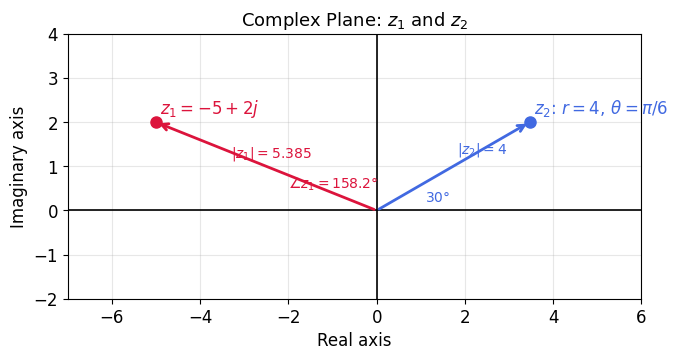

In [4]:
# ============================================================
# Figure 2: Plot z1 and z2 on the complex plane
# ============================================================

def plot_complex_vector(ax, x, y, color, label, offset=(0.15, 0.15)):
    """Draw a labeled arrow from origin to (x, y) on axes ax."""
    ax.annotate('', xy=(x, y), xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.0))
    ax.plot(x, y, 'o', color=color, markersize=8)
    ax.text(x + offset[0], y + offset[1], label, color=color, fontsize=12)

fig, ax = plt.subplots(figsize=(7, 7))
ax.axhline(0, color='black', linewidth=1.2)
ax.axvline(0, color='black', linewidth=1.2)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plot_complex_vector(ax, x1, y1, 'crimson',    r'$z_1 = -5+2j$',          offset=(0.1, 0.2))
plot_complex_vector(ax, x2, y2, 'royalblue',  r'$z_2$: $r=4,\,\theta=\pi/6$', offset=(0.1, 0.2))

# Annotate modulus and angle for z1
ax.text(x1/2 - 0.8, y1/2 + 0.2, f'$|z_1|={r1:.3f}$', color='crimson', fontsize=10)
ax.text(x1/2 + 0.5, y1/4,       f'$\\angle z_1={np.degrees(theta1):.1f}°$', color='crimson', fontsize=10)

# Annotate modulus and angle for z2
ax.text(x2/2 + 0.1, y2/2 + 0.3, f'$|z_2|={r2}$', color='royalblue', fontsize=10)
ax.text(1.1, 0.2, r'$30°$', color='royalblue', fontsize=10)

ax.set_xlim(-7, 6)
ax.set_ylim(-2, 4)
ax.set_xlabel('Real axis', fontsize=12)
ax.set_ylabel('Imaginary axis', fontsize=12)
ax.set_title(r'Complex Plane: $z_1$ and $z_2$', fontsize=13)
plt.tight_layout()
plt.show()

---
### Task: Repeat for $z_3$ and $z_4$ (using as little algebra as possible)

Given:
$$\Re\{z_3\} = 5, \quad \Im\{z_3\} = -2$$
$$|z_4| = 4, \quad \angle z_4 = -\pi/6 \text{ rad}$$

**Key Insight — Use Symmetry!**

Notice that:
- $z_3 = (5, -2)$ is the **reflection of $z_1 = (-5, 2)$** across **both axes** (i.e., complex conjugate of $-z_1$). More usefully: $z_3$ has the **same modulus** as $z_1$ but its angle is $-\angle z_1 + \pi$... but let's be smarter:

  Since $z_1 = -5 + 2j$ and $z_3 = 5 - 2j$, we see $z_3 = -z_1^* = -(z_1^*)$.  
  But the simplest observation: $z_3$ is simply the **reflection of $z_1$ through the origin** negated in imaginary part — actually $z_3 = \overline{(-z_1)} = -\bar{z_1}$.  

  **Simplest:** $|z_3| = |z_1| = \sqrt{29}$, $\angle z_3 = \arctan(-2/5) = -\angle z_2^*$… 
  
  Let's just compute directly and note the symmetry:

- $z_4 = (4, -\pi/6)$: this is the **reflection of $z_2$** across the real axis (complex conjugate). So $|z_4| = |z_2| = 4$ and $\angle z_4 = -\angle z_2 = -\pi/6$. **No computation needed** — just flip the sign of the imaginary part of $z_2$.

> 💡 **Insight:** $z_3$ and $z_4$ are simply the **complex conjugates** of $z_1$ and $z_2$ reflected appropriately. Recognizing symmetry avoids redundant calculations.


In [5]:
# ============================================================
# Step-by-step computation for z3 and z4
# ============================================================

# --- z3: Cartesian → Polar ---
x3, y3 = 5, -2
r3 = np.sqrt(x3**2 + y3**2)
theta3 = np.arctan2(y3, x3)   # x3 > 0, so no correction needed

print("=== z3 ===")
print(f"  Cartesian:  x3 = {x3},  y3 = {y3}")
print(f"  Modulus:    |z3| = sqrt({x3}^2 + ({y3})^2) = sqrt({x3**2+y3**2}) = {r3:.4f}")
print(f"  Angle:      theta3 = arctan({y3}/{x3}) = {theta3:.4f} rad = {np.degrees(theta3):.2f} deg")
print(f"  Note: x3 > 0, so NO pi correction needed.")
print(f"  Symmetry check: |z3| = |z1| = {r1:.4f} ✓  (same modulus, reflected angle)")
print()

# --- z4: Polar → Cartesian ---
r4     = 4
theta4 = -np.pi / 6

x4 = r4 * np.cos(theta4)
y4 = r4 * np.sin(theta4)

print("=== z4 ===")
print(f"  Polar:      r4 = {r4},  theta4 = -pi/6 = {theta4:.4f} rad")
print(f"  Re{{z4}} = 4 cos(-pi/6) = 4 cos(pi/6)  = {x4:.4f}   (cosine is even)")
print(f"  Im{{z4}} = 4 sin(-pi/6) = -4 sin(pi/6) = {y4:.4f}  (sine is odd)")
print(f"  Symmetry: z4 is the complex conjugate of z2 → same real part, negated imag part ✓")

=== z3 ===
  Cartesian:  x3 = 5,  y3 = -2
  Modulus:    |z3| = sqrt(5^2 + (-2)^2) = sqrt(29) = 5.3852
  Angle:      theta3 = arctan(-2/5) = -0.3805 rad = -21.80 deg
  Note: x3 > 0, so NO pi correction needed.
  Symmetry check: |z3| = |z1| = 5.3852 ✓  (same modulus, reflected angle)

=== z4 ===
  Polar:      r4 = 4,  theta4 = -pi/6 = -0.5236 rad
  Re{z4} = 4 cos(-pi/6) = 4 cos(pi/6)  = 3.4641   (cosine is even)
  Im{z4} = 4 sin(-pi/6) = -4 sin(pi/6) = -2.0000  (sine is odd)
  Symmetry: z4 is the complex conjugate of z2 → same real part, negated imag part ✓


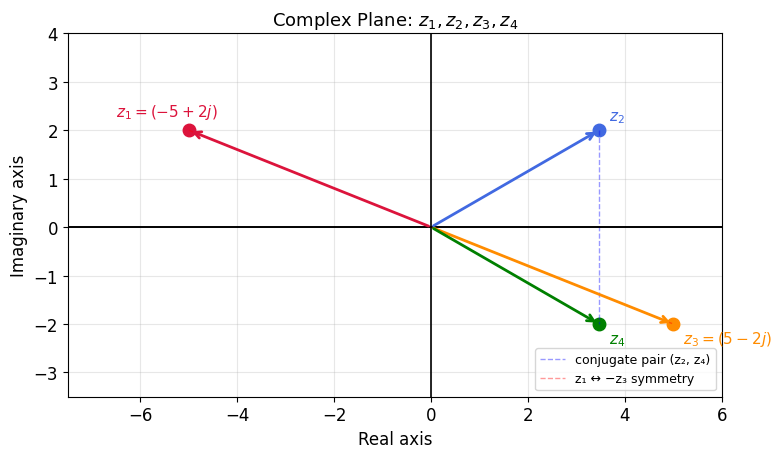


Summary Table:
Point  x (Re)     y (Im)     r = |z|      theta (rad)    theta (deg) 
-----------------------------------------------------------------
z1     -5.0000    2.0000     5.3852       2.7611         158.20      
z2     3.4641     2.0000     4.0000       0.5236         30.00       
z3     5.0000     -2.0000    5.3852       -0.3805        -21.80      
z4     3.4641     -2.0000    4.0000       -0.5236        -30.00      


In [6]:
# ============================================================
# Figure 3: All four points on the complex plane
# ============================================================

fig, ax = plt.subplots(figsize=(8, 7))
ax.axhline(0, color='black', linewidth=1.2)
ax.axvline(0, color='black', linewidth=1.2)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

points = [
    (x1, y1, 'crimson',    r'$z_1=(-5+2j)$',    (-1.5,  0.3)),
    (x2, y2, 'royalblue',  r'$z_2$',             ( 0.2,  0.2)),
    (x3, y3, 'darkorange', r'$z_3=(5-2j)$',      ( 0.2, -0.4)),
    (x4, y4, 'green',      r'$z_4$',             ( 0.2, -0.4)),
]

for xi, yi, col, lbl, off in points:
    ax.annotate('', xy=(xi, yi), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color=col, lw=2.0))
    ax.plot(xi, yi, 'o', color=col, markersize=9)
    ax.text(xi + off[0], yi + off[1], lbl, color=col, fontsize=11)

# Dashed lines showing conjugate symmetry
ax.plot([x2, x4], [y2, y4], 'b--', alpha=0.4, lw=1, label='conjugate pair (z₂, z₄)')
ax.plot([x1, x3], [y1, y3], 'r--', alpha=0.4, lw=1, label='z₁ ↔ −z₃ symmetry')
ax.axhline(0, color='black', linewidth=1.2)  # redraw on top

ax.set_xlim(-7.5, 6)
ax.set_ylim(-3.5, 4)
ax.set_xlabel('Real axis', fontsize=12)
ax.set_ylabel('Imaginary axis', fontsize=12)
ax.set_title(r'Complex Plane: $z_1, z_2, z_3, z_4$', fontsize=13)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

print("\nSummary Table:")
print(f"{'Point':<6} {'x (Re)':<10} {'y (Im)':<10} {'r = |z|':<12} {'theta (rad)':<14} {'theta (deg)':<12}")
print("-"*65)
for lbl, xi, yi, ri, ti in [
    ('z1', x1, y1, r1, theta1),
    ('z2', x2, y2, r2, theta2),
    ('z3', x3, y3, r3, theta3),
    ('z4', x4, y4, r4, theta4),
]:
    print(f"{lbl:<6} {xi:<10.4f} {yi:<10.4f} {ri:<12.4f} {ti:<14.4f} {np.degrees(ti):<12.2f}")

---
### 4. Vector Interpretation — Scaling and Addition

Since complex numbers are **vectors**, the following operations have the same meaning as in two-dimensional vector algebra:

- **Scaling:** $cz$ where $c$ is a real constant — scales the vector by $c$
- **Summation:** $z_1 + z_2$ — tip-to-tail vector addition

Summation is **easiest in Cartesian coordinates** (just add real and imaginary parts separately):

$$z_1 + z_2 = (\Re\{z_1\} + \Re\{z_2\}) + j(\Im\{z_1\} + \Im\{z_2\})$$

> ⚠️ **Common Mistake:** Trying to add vectors using polar coordinates directly — you **cannot** simply add the moduli or the angles. You must convert to Cartesian first.


In [7]:
# ============================================================
# Vector Scaling and Addition Demo
# ============================================================

# Use z1 and z2 as our two vectors (as Python complex numbers)
z1 = complex(x1, y1)   # -5 + 2j
z2 = complex(x2, y2)   # 2√3 + 2j

# --- Scaling ---
c  = 2.0
cz1 = c * z1
print(f"z1        = {z1}")
print(f"c = {c}")
print(f"c * z1    = {cz1}   (doubles each component)")
print()

# --- Summation ---
z_sum = z1 + z2
print(f"z1        = {z1}")
print(f"z2        = ({x2:.4f}) + ({y2:.4f})j")
print(f"z1 + z2   = ({z1.real:.4f} + {z2.real:.4f}) + j({z1.imag:.4f} + {z2.imag:.4f})")
print(f"          = {z_sum.real:.4f} + {z_sum.imag:.4f}j")
print(f"|z1 + z2| = {abs(z_sum):.4f}")
print(f"∠(z1+z2)  = {np.angle(z_sum):.4f} rad")

z1        = (-5+2j)
c = 2.0
c * z1    = (-10+4j)   (doubles each component)

z1        = (-5+2j)
z2        = (3.4641) + (2.0000)j
z1 + z2   = (-5.0000 + 3.4641) + j(2.0000 + 2.0000)
          = -1.5359 + 4.0000j
|z1 + z2| = 4.2847
∠(z1+z2)  = 1.9374 rad


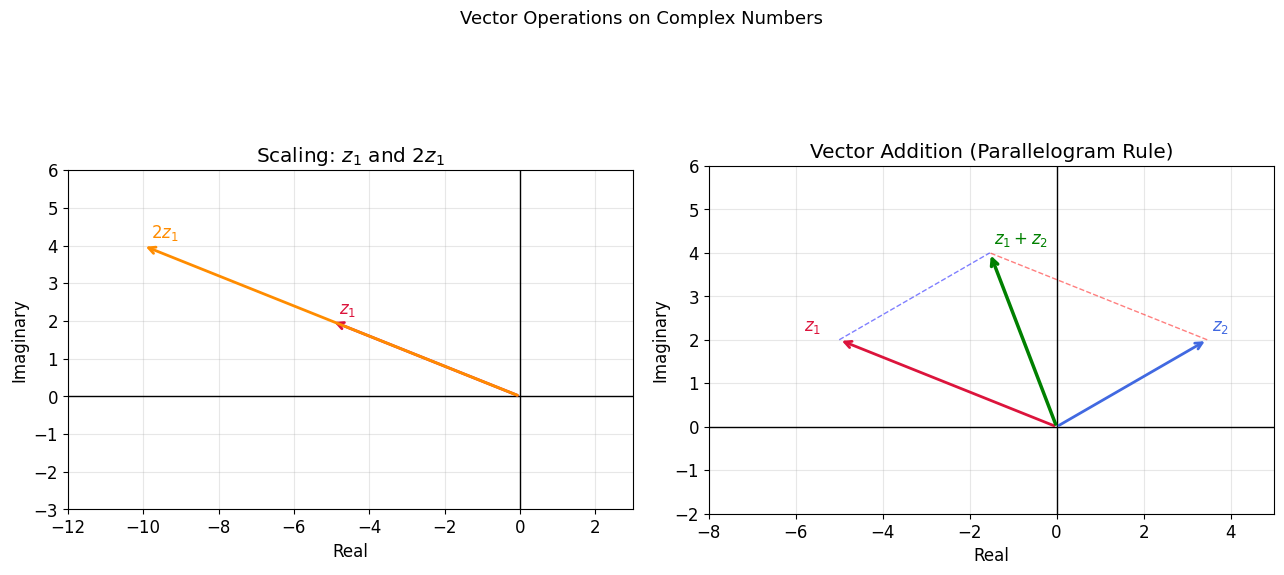

Verification using Python's built-in complex arithmetic:
  z1 = (-5+2j)
  z2 = 3.4641+2.0000j
  z1 + z2 = -1.5359+4.0000j
  2 * z1  = (-10+4j)


In [8]:
# ============================================================
# Figure 4: Vector addition — parallelogram rule
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# ---- Left panel: Scaling ----
ax = axes[0]
ax.axhline(0, color='black', lw=1); ax.axvline(0, color='black', lw=1)
ax.grid(True, alpha=0.3); ax.set_aspect('equal')

for vec, col, lbl in [(z1, 'crimson', r'$z_1$'), (c*z1, 'darkorange', r'$2z_1$')]:
    ax.annotate('', xy=(vec.real, vec.imag), xytext=(0,0),
                arrowprops=dict(arrowstyle='->', color=col, lw=2))
    ax.text(vec.real + 0.2, vec.imag + 0.2, lbl, color=col, fontsize=12)

ax.set_xlim(-12, 3); ax.set_ylim(-3, 6)
ax.set_xlabel('Real'); ax.set_ylabel('Imaginary')
ax.set_title('Scaling: $z_1$ and $2z_1$')

# ---- Right panel: Addition (parallelogram rule) ----
ax = axes[1]
ax.axhline(0, color='black', lw=1); ax.axvline(0, color='black', lw=1)
ax.grid(True, alpha=0.3); ax.set_aspect('equal')

# z1
ax.annotate('', xy=(z1.real, z1.imag), xytext=(0,0),
            arrowprops=dict(arrowstyle='->', color='crimson', lw=2))
ax.text(z1.real - 0.8, z1.imag + 0.2, r'$z_1$', color='crimson', fontsize=12)

# z2
ax.annotate('', xy=(z2.real, z2.imag), xytext=(0,0),
            arrowprops=dict(arrowstyle='->', color='royalblue', lw=2))
ax.text(z2.real + 0.1, z2.imag + 0.2, r'$z_2$', color='royalblue', fontsize=12)

# z1 + z2
ax.annotate('', xy=(z_sum.real, z_sum.imag), xytext=(0,0),
            arrowprops=dict(arrowstyle='->', color='green', lw=2.5))
ax.text(z_sum.real + 0.1, z_sum.imag + 0.2, r'$z_1+z_2$', color='green', fontsize=12)

# Dashed parallelogram sides
ax.plot([z1.real, z_sum.real], [z1.imag, z_sum.imag], 'b--', alpha=0.5, lw=1)
ax.plot([z2.real, z_sum.real], [z2.imag, z_sum.imag], 'r--', alpha=0.5, lw=1)

ax.set_xlim(-8, 5); ax.set_ylim(-2, 6)
ax.set_xlabel('Real'); ax.set_ylabel('Imaginary')
ax.set_title('Vector Addition (Parallelogram Rule)')

plt.suptitle('Vector Operations on Complex Numbers', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("Verification using Python's built-in complex arithmetic:")
print(f"  z1 = {z1}")
print(f"  z2 = {z2:.4f}")
print(f"  z1 + z2 = {z1 + z2:.4f}")
print(f"  2 * z1  = {2*z1}")

---
## Summary & Key Takeaways

| Concept | Formula |
|---|---|
| Cartesian → Polar | $r = \sqrt{x^2+y^2}$, $\;\theta = \text{arctan2}(y,x)$ |
| Polar → Cartesian | $x = r\cos\theta$, $\;y = r\sin\theta$ |
| Add $\pi$ to $\theta$? | Yes, if and only if $x < 0$ |
| Vector addition | Add real and imaginary parts separately |
| Vector scaling | Multiply each component by $c$ |

### ⚠️ Mistakes to Avoid

1. **Forgetting to add $\pi$** when computing the angle of a point in the 2nd or 3rd quadrant. Always use `np.arctan2(y, x)` in Python — it handles this automatically.

2. **Using `np.arctan(y/x)` instead of `np.arctan2(y, x)`** — this loses the sign of the denominator, placing the angle in the wrong quadrant half the time.

3. **Trying to add complex numbers using their polar forms** — you must convert to Cartesian first, or use Python's built-in complex type.

4. **Confusing radians and degrees** — all Python trigonometric functions expect **radians**. Use `np.degrees()` / `np.radians()` to convert.


In [9]:
# ============================================================
# Demonstration: arctan vs arctan2 — the classic mistake
# ============================================================

test_cases = [
    ( 5,  2, 'Q1'),
    (-5,  2, 'Q2'),  # ← requires +pi
    (-5, -2, 'Q3'),  # ← requires +pi (or -pi)
    ( 5, -2, 'Q4'),
]

print(f"{'Point':<14} {'Quadrant':<8} {'arctan(y/x) [WRONG]':<24} {'arctan2(y,x) [CORRECT]':<24}")
print("-" * 72)
for x_, y_, q in test_cases:
    wrong   = np.arctan(y_ / x_)          # single-arg arctan
    correct = np.arctan2(y_, x_)           # two-arg arctan2
    flag = "<-- ERROR" if not np.isclose(wrong, correct) else ""
    print(f"({x_:+d},{y_:+d})      {q:<8} {wrong:>+8.4f} rad ({np.degrees(wrong):>+8.2f}°)    "
          f"{correct:>+8.4f} rad ({np.degrees(correct):>+8.2f}°) {flag}")

Point          Quadrant arctan(y/x) [WRONG]      arctan2(y,x) [CORRECT]  
------------------------------------------------------------------------
(+5,+2)      Q1        +0.3805 rad (  +21.80°)     +0.3805 rad (  +21.80°) 
(-5,+2)      Q2        -0.3805 rad (  -21.80°)     +2.7611 rad ( +158.20°) <-- ERROR
(-5,-2)      Q3        +0.3805 rad (  +21.80°)     -2.7611 rad ( -158.20°) <-- ERROR
(+5,-2)      Q4        -0.3805 rad (  -21.80°)     -0.3805 rad (  -21.80°) 
